# Model 1 — Logistic Regression for Next-Day Direction

This notebook predicts whether **tomorrow’s closing price** will be higher than today’s using daily OHLCV data from the Kaggle *Huge Stock Market Dataset*.

The workflow:
- Load multiple tickers from raw `.txt` or `.csv` files.  
- Create a clean supervised dataset with simple technical features.  
- Split by time (train on past, test on future).  
- Standardize features and train a **Logistic Regression** classifier.  
- Evaluate with Accuracy, F1, ROC–AUC, confusion matrix, and probability plots.


In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


Kaggle Huge Stock Market Dataset

1) Locate dataset files

The dataset is stored as one file per ticker under `data/raw/Stocks/`. This cell sets that directory and builds a list of all ticker files, accepting  `.txt`. Constructing this list once allows the rest of the notebook to iterate over a consistent set of tickers regardless of file extension details.


In [8]:
from pathlib import Path

# Your dataset lives here
DATA_DIR = Path("../data/raw/Stocks")

# collect .txt 
files = list(DATA_DIR.glob("*.txt")) 

print(f"Total files found: {len(files)}")
# peek at the first few
files[:5]


Total files found: 7195


[WindowsPath('../data/raw/Stocks/a.us.txt'),
 WindowsPath('../data/raw/Stocks/aa.us.txt'),
 WindowsPath('../data/raw/Stocks/aaap.us.txt'),
 WindowsPath('../data/raw/Stocks/aaba.us.txt'),
 WindowsPath('../data/raw/Stocks/aac.us.txt')]

2) Load a subset of tickers

To iterate quickly, this loader reads only the first 50 tickers (you can increase this later). Each file is parsed with `pandas.read_csv` and augmented with a `Ticker` column derived from the filename (e.g., `a.us.txt → a`). Individual per-ticker frames are concatenated into one large DataFrame with columns like `Date, Open, High, Low, Close, Volume, OpenInt, Ticker`. At this point we have a multi-asset panel of daily bars ready for preprocessing.


In [3]:
import pandas as pd

dfs = []
for f in files[:50]:  # take 50 tickers first so it runs fast
    try:
        df = pd.read_csv(f, engine="python")  # detect delimiter automatically
        ticker = f.stem.split('.')[0]         # e.g. "a.us.txt" -> "a"
        df["Ticker"] = ticker
        dfs.append(df)
    except Exception as e:
        print(f"Skipping {f.name}: {e}")

data = pd.concat(dfs, ignore_index=True)
print("Shape:", data.shape)
data.head()


Shape: (141355, 8)


,Date,Open,High,Low,Close,Volume,OpenInt,Ticker
0,1999-11-18,30.713,33.754,27.002,29.702,66277506,0,a
1,1999-11-19,28.986,29.027,26.872,27.257,16142920,0,a
2,1999-11-22,27.886,29.702,27.044,29.702,6970266,0,a
3,1999-11-23,28.688,29.446,27.002,27.002,6332082,0,a
4,1999-11-24,27.083,28.309,27.002,27.717,5132147,0,a


3) Preprocess → target + features

This step transforms raw OHLCV into a supervised learning table. Dates are parsed and the data is sorted by `(Ticker, Date)` to maintain temporal order per asset. The binary target is created per ticker by shifting `Close` forward one day and labeling `1` when `NextClose > Close`, `0` otherwise. A compact feature set is then computed: the intraday return `(Close−Open)/Open` captures direction and session magnitude; the normalized range `(High−Low)/Open` approximates daily volatility; and `vol_chg` is the per-ticker percentage change in volume as a crude attention signal. Short rolling context is added with 5- and 10-day moving averages (level) and 5- and 10-day percentage changes (momentum). Because rolling operations and percentage changes can introduce boundary NaNs, rows with missing values in the selected features are dropped, yielding a clean feature matrix and aligned target.


In [4]:
# --- preprocessing
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date","Open","High","Low","Close","Volume"]).sort_values(["Ticker","Date"])

# target: next-day up (1) vs down (0) per ticker
data["NextClose"] = data.groupby("Ticker")["Close"].shift(-1)
data = data.dropna(subset=["NextClose"])
data["Target"] = (data["NextClose"] > data["Close"]).astype(int)

# simple features
data["ret_1d"]  = (data["Close"] - data["Open"]) / data["Open"]
data["range"]   = (data["High"] - data["Low"]) / data["Open"]
data["vol_chg"] = data.groupby("Ticker")["Volume"].pct_change().fillna(0)

# short rolling context
for w in [5, 10]:
    data[f"ma_{w}"]  = data.groupby("Ticker")["Close"].transform(lambda s: s.rolling(w, min_periods=1).mean())
    data[f"ret_{w}"] = data.groupby("Ticker")["Close"].transform(lambda s: s.pct_change(w))

feature_cols = ["ret_1d","range","vol_chg","ma_5","ma_10","ret_5","ret_10"]
data = data.dropna(subset=feature_cols).copy()

print("Rows after prep:", len(data))
print("Class balance (1=up):")
print(data["Target"].value_counts(normalize=True).round(3))


Rows after prep: 140805
Class balance (1=up):
Target
0    0.516
1    0.484
Name: proportion, dtype: float64


4) Chronological train/test split (avoid leakage)

Financial data must be split by time to avoid look-ahead. This cell computes the 80th percentile of the `Date` column and assigns all earlier observations to training and all later observations to testing. The result is a causal split: the model is trained only on the past and evaluated on the future, which better reflects real deployment.


In [5]:
# global chronological split using Date quantile
split_date = data["Date"].quantile(0.8)
train_idx = data["Date"] <= split_date
test_idx  = data["Date"] >  split_date

X_train = data.loc[train_idx, feature_cols].to_numpy()
y_train = data.loc[train_idx, "Target"].to_numpy()
X_test  = data.loc[test_idx,  feature_cols].to_numpy()
y_test  = data.loc[test_idx,  "Target"].to_numpy()

X_train.shape, X_test.shape


((112677, 7), (28128, 7))

5) Train Logistic Regression

Before fitting, any residual `NaN` or infinite values in the feature arrays are converted to zeros to prevent numerical issues from percent changes or rolling windows. Features are then standardized with `StandardScaler`, which is fit on the training set and applied to both train and test so that each feature has mean zero and unit variance under the training distribution. The logistic regression classifier models the conditional probability of an up day with a sigmoid of a linear combination of features; training maximizes the conditional log-likelihood. After fitting, hard class predictions come from a 0.5 threshold, while `predict_proba` yields calibrated probabilities for class `1` (“up”), which are used for rank-based metrics and calibration plots.


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --- Clean NaN / infinite values before scaling
import numpy as np

X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
y_pred = logreg.predict(X_test_s)
y_prob = logreg.predict_proba(X_test_s)[:,1]


6) Evaluate + plots

This evaluation cell summarizes performance from three complementary angles. Accuracy measures overall correctness across both classes, while the F1 score for the positive class balances precision (purity of predicted ups) and recall (coverage of actual ups), which is informative when the classifier is conservative about predicting rises. ROC–AUC evaluates threshold-free ranking quality based on predicted probabilities; values near 0.5 indicate random ranking and values near 1.0 indicate strong separability. The classification report breaks out precision, recall, and F1 per class together with support counts, making any skew toward “down” immediately visible. The confusion matrix visualizes true/false positives and negatives, and the probability histogram reveals calibration and confidence—when mass concentrates near 0.5, features provide weak separation, which is typical for next-day direction with basic technical indicators.


Accuracy: 0.5064
F1 Score: 0.1038
ROC-AUC : 0.521

Classification Report:
               precision    recall  f1-score   support

           0     0.5069    0.9432    0.6594     14250
           1     0.4985    0.0579    0.1038     13878

    accuracy                         0.5064     28128
   macro avg     0.5027    0.5006    0.3816     28128
weighted avg     0.5027    0.5064    0.3853     28128



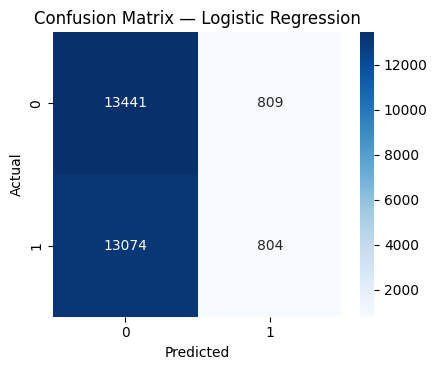

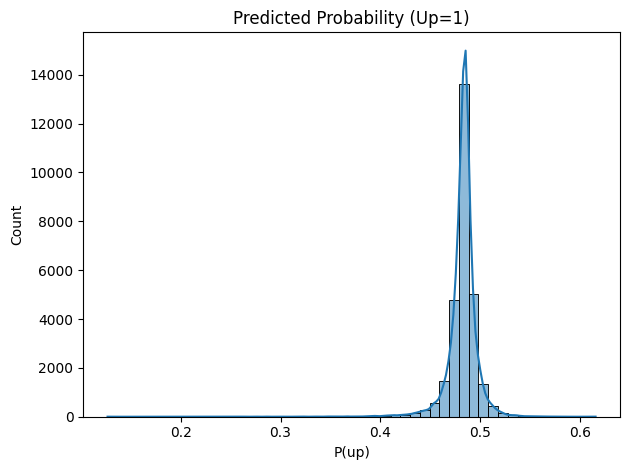

In [7]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns, matplotlib.pyplot as plt

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5,3.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

sns.histplot(y_prob, bins=50, kde=True)
plt.title("Predicted Probability (Up=1)")
plt.xlabel("P(up)"); plt.tight_layout(); plt.show()
